# Assignment 3 – Robot in a maze

In the  fourth assignment, you will delve into the application of RL algorithms to address the real-world challenge of navigating a robot through a maze dubbed 'robot in a maze'. The primary objectives of this assignment include:

 -   Formalizing a practical problem into a Markov Decision Process (MDP).
 -   Gaining familiarity with the OpenAI Gym framework (recently renamed as Gymnasium) and utilizing it to implement RL agents.
 -   Applying SARSA and Q-learning algorithms to solve the 'robot in a maze' MDP problem.
 -   Evaluating the outcomes of the reinforcement learning process and interpreting your findings.
 -   Reflecting on the distinctions between the two types of RL algorithms employed.

By accomplishing these objectives, you will not only enhance your understanding of RL algorithms but also develop practical skills in formulating and solving complex problems in the context of autonomous navigation within a maze.

In this assignment, you will be developing a robot to navigate its way through a maze. The project is divided into three parts (5 subtasks).

  1. In the first part, you will familiarize yourself with the OpenAI Gym/Gymnasium framework.
  2. In the second part, we have implemented the environment for you based on the Gym/Gymnasium framework. Your tasks include:  
     2.1. formalizing the problem as an MDP model,    
     2.2. implementing your own RL agents, and      
     2.3. training them to find the shortest route out of a maze.
  3. Finally, in the third part, you will evaluate and interpret the results obtained from the implemented RL agents


## 1. OpenAI gym

Gym/Gymnasium (https://gymnasium.farama.org/) is a widely used standard toolkit for developing and comparing reinforcement learning algorithms. Gymnasium is the maintained fork of OpenAI’s Gym library (more on this recent change is available if you're interested: https://farama.org/Announcing-The-Farama-Foundation).

Gym/Gymnasium makes no assumptions about the structure of your agent and is compatible with any machine learning library, such as TensorFlow or Theano.

The library is a collection of test problems — environments — that you can use to develop your reinforcement learning algorithms. These environments have a shared interface, allowing you to write general algorithms.

First, we download and install the Gym/Gymnasium library. Then, import the Gymnasium class.

In [88]:
!pip install gymnasium


We are now going to explain how the RL framework of gym works. 
- An **ENVIRONMENT**, 
- You also have an **AGENT**,
- In MDP problems, such as ours, the **ENVIRONMENT** provides an **OBSERVATION**, which represents the state of the **ENVIRONMENT** at the current moment.
- The agent takes an **ACTION** based on its **OBSERVATION**,
<!-- When a single **ACTION** is chosen and fed to our **ENVIRONMENT**, the **ENVIRONMENT** measures how good the action was taken and produces a **REWARD**, which is usually a numeric value. -->
- When the agent takes an ACTION, the ENVIRONMENT assesses the effectiveness of the action and generates a REWARD, which is usually a numeric value.

Please read the 'Basic usage' https://gymnasium.farama.org/content/basic_usage/ for better understanding the framework.  And do not forget import gymnasium before running other codes.

In [89]:
import gymnasium as gym

 ## 2. Tasks

Next, you will tackle a practical Markov Decision Process (MDP) problem, the 'robot in a maze,' based on the gym framework. Your task involves implementing an RL agent and training it to discover the shortest route to achieve the maze goal. In this MDP, the environment is represented as a grid world (a maze), with the agent being a robot. At each time step, the robot begins at a random location and can move within the grid world. The overarching objective is to find the way out, reaching the final location. Consequently, you will need to identify a fixed goal position within the maze.

### 2.1 Model the practical task into a MDP

To solve a RL problem, we start with formalizing the problem into a MDP model. Please describe this MDP model in your report. 

Notice: No empricial data provided in this assignment, so the point of 'data description and exploration' will be given to this step. 

While exploring your MDP model, you shall think about questions such as:
- What is the environment? How does it look like?
- What simulated data can your RL agent observe from the environment? How does it look like?
- Which data is considered as the state? Which data is considered as the reward?

#### Set up the environment

There is no need to implement your own environment; you should use the environment provided in the file **environment.py**. However, please ensure to take a look at it so that you understand the inner workings of this environment.

The core gym interface is **Env**, which serves as the unified environment interface. The following are the Env methods you should be familiar with:

- reset(self): Reset the environment's state and return the observation.
- step(self, action): Advance the environment by one timestep and return the observation, reward, done, and info.
- render(self, mode='rgb_array'): Render one frame of the environment. The default mode will produce something human-friendly, such as a pop up window. However, in this assignment, there is no need to create a pop-up window.

Please note that you need to install the [mazelab](https://github.com/yupei-du/mazelab.git) package, from **Yupei Du's** repository, to run the environment (a file with required packages is also provided). If you run the cell below for the first time, make sure to restart the IPython notebook at least once.


In [90]:
!git clone https://github.com/yupei-du/mazelab.git
!pip install -e mazelab
!pip install pandas
!pip install seaborn

fatal: destination path 'mazelab' already exists and is not an empty directory.


Obtaining file:///C:/Users/henkd/OneDrive/Bureaublad/GitProjectjes/APML-Assignment-1/assignment-3/mazelab
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for mazelab (pyproject.toml): started
  Building editable for mazelab (pyproject.toml): finished with status 'done'
  Created wheel for mazelab: filename=mazelab-0.2.0-0.editable-py3-none-any.whl size=4990 sha256=d8ff1c0bac179607c53e2b2689b97994cb2ff7ca82230c39eec3f3c7a70bccaf
  Stored in directory: C:\Users\henkd\AppData\Local\Temp\pip-ephem-wheel-cache-sh96atbf\wheels\aa\54

You can now check whether the required packages (e.g. mazela, pandas, tqdm, seaborn) are installed. Please install the ones are missing. 

ATTENTION: To run the given code, please use the python version 3.7-3.9, and the numpy version < 1.23

In [91]:
# conda list
# !pip install -r required_packages.txt
!pip list

Package                   Version     Editable project location
------------------------- ----------- ---------------------------------------------------------------------------------------
anyio                     4.12.1
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.1
async-lru                 2.0.5
attrs                     25.4.0
babel                     2.17.0
beautifulsoup4            4.14.3
bleach                    6.2.0
certifi                   2026.1.4
cffi                      2.0.0
charset-normalizer        3.4.4
cloudpickle               3.1.2
colorama                  0.4.6
comm                      0.2.3
contourpy                 1.2.0
cycler                    0.11.0
debugpy                   1.8.19
decorator                 5.2.1
defusedxml                0.7.1
exceptiongroup            1.3.1
executing                 2.2.1
Farama-Notifications      0.0.4
fastjsonschema            2.21.

We also provide a few helper functions to make it easier to debug your agents. 
 - `animate_run` will enable you to see the agent's behavior. It takes a list of images which can be produced by the `env.render` function of the environment
 - `visualize_agent_brain` will provide you with a way to visualize the agents learned q_table. Use it after you have implemented and trained your agents. The first plot will show the highest q-value per state (position on the map) and the second will tell you which action the agent would choose at that state/position. It takes the environment and the agent as input.

Below you will find a basic example of how the animation function works. Please notice that: whenever you **reset()** the environment, the agent will start at a random position (a different state). 

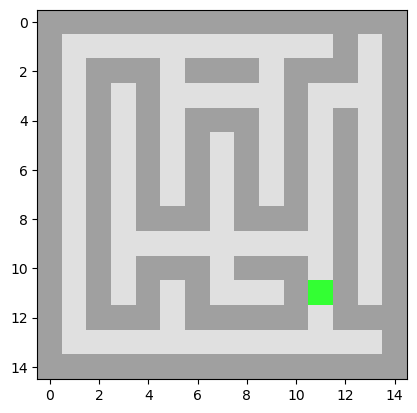

In [92]:
# The helper functions

from IPython import get_ipython
import random
from mazelab.mazelab.generators import random_maze
from mazelab.mazelab.generators import morris_water_maze
import matplotlib.pyplot as plt
from IPython import display
from mazelab.mazelab.solvers import dijkstra_solver
import seaborn as sns
from tqdm.notebook import tqdm
from environment import TaskEnv
from typing import Tuple, List
import itertools as it
import numpy as np
import pandas as pd
from sklearn.metrics import auc

def animate_run(data:List[np.ndarray]):
    init_img = data[0]
    remaining_img = data[1:]
    img_container = plt.imshow(init_img)  # only call this once
    for img in remaining_img:
        img_container.set_data(img)  # just update the data
        display.display(plt.gcf())
        display.clear_output(wait=True)


def visualize_agent_brain(agent, env: TaskEnv):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.set_title("Highest state value at position (x,y)")
    state_value_map = agent.q_table.max(axis=2)
    sns.heatmap(state_value_map, ax=ax1)

    ax2.set_title("Chosen action at position (x,y)")
    n = env.action_space.n + 1
    path = env.maze.objects.free.positions
    decisions_map = np.array([[x_, y_, agent.select_action([x_, y_]) + 1] for x_, y_ in path])
    state_action_map = np.zeros_like(agent.q_table.max(axis=2))
    state_action_map[decisions_map[:, 0], decisions_map[:, 1]] = decisions_map[:, 2]
    cmap = sns.color_palette("viridis", n)
    sns.heatmap(state_action_map, cmap=cmap, ax=ax2)
    colorbar = ax2.collections[0].colorbar
    r = (colorbar.vmax) - colorbar.vmin
    colorbar.set_ticks([colorbar.vmin + r / n * (0.5 + i) for i in range(n)])
    colorbar.set_ticklabels(['N/A', 'north', 'south', 'west', 'east'])
    fig.tight_layout()
    return plt.show()


env = TaskEnv()
env.reset()
impassable_array = env.unwrapped.maze.to_impassable()
motions = env.unwrapped.motions
start = env.unwrapped.maze.objects.agent.positions[0]
goal = env.unwrapped.maze.objects.goal.positions[0]
actions = dijkstra_solver(impassable_array, motions, start, goal)
print(actions)

imgs = []
rewards = 0.0
for action in actions:
    _, reward, _, _ = env.step(action)
    rewards += reward
    imgs.append(env.render("rgb_array"))
print(rewards)

animate_run(imgs)
plt.show()

### 2.2  Implement the agents 

In this part, you are expected to implement two RL agents. 

- Agent 1 uses the Q-learning algorithm to learn the optimal solution
- Agent 2 uses the SARSA algorithm to learn the optimal solution. To decide the action to take at each time step,  this agent uses the epsilon greedy action selection.

Here, we have also provided an example agent: the Random Agent.  It follows a random policy to move at each step (randomly selecting an action). You can use this example agent as a baseline to evaluate your agents.


In [93]:
# Random agent
class RandomAgent():
    def __init__(self,
                 env: TaskEnv,
                 exploration_rate: float = None,
                 learning_rate: float = None,
                 discount_factor: float = None) -> int:
        self.epsilon = 1  # A random agent "explores" always, so epsilon will be 1
        self.alpha = 0  # A random agent never learns, so there's no need for a learning rate
        self.gamma = 0  # A random agent does not update it's q-table. Hence, it's zero.
        self.q_table = np.zeros(env.observation_space.shape + (env.action_space.n, ), dtype=float)
        self.actions = env.action_space

    def select_action(self, state: Tuple[int, int], use_greedy_strategy: bool = False) -> int:
        if not use_greedy_strategy:
            if random.random() < self.epsilon:
                next_action = self.actions.sample()
                return next_action

        x, y = state
        max_val = np.max(self.q_table[x, y, :])
        find_max_val = np.where(self.q_table[x, y, :] == max_val)
        next_action = np.random.choice(find_max_val[0])
        return next_action

    def learn(self, state, action, next_state, next_action, reward, done):
        return None


In [94]:
# TODO: implement two agents
class sarsaAgent():
    def __init__(self, env: TaskEnv,
                 exploration_rate: float = 0.1,
                 learning_rate: float = 0.2,
                 discount_factor: float = 1.0):
        self.epsilon = exploration_rate
        self.alpha = learning_rate
        self.gamma = discount_factor
        self.q_table = np.zeros(env.observation_space.shape + (env.action_space.n, ), dtype=float)
        self.actions = env.action_space
        

    def select_action(self, state: Tuple[int, int], use_greedy_strategy: bool = False) -> int:
        if not use_greedy_strategy:
            if random.random() < self.epsilon:
                next_action = self.actions.sample()
                return next_action

        x, y = state
        max_val = np.max(self.q_table[x, y, :])
        find_max_val = np.where(self.q_table[x, y, :] == max_val)
        next_action = np.random.choice(find_max_val[0])
        return next_action


    def learn(self, state, action, next_state, next_action, reward, done):
        x ,y = state
        next_x, next_y = next_state
        td_target = reward + self.gamma * self.q_table[next_x, next_y, next_action] * (1 - int(done))
        td_delta = td_target - self.q_table[x, y, action]
        self.q_table[x, y, action] += self.alpha * td_delta

class qLearningAgent():
    def __init__(self, env: TaskEnv,
                 exploration_rate: float = 0.1,
                 learning_rate: float = 0.2,
                 discount_factor: float = 1.0):
        self.epsilon = exploration_rate
        self.alpha = learning_rate
        self.gamma = discount_factor
        self.q_table = np.zeros(env.observation_space.shape + (env.action_space.n, ), dtype=float)
        self.actions = env.action_space
        

    def select_action(self, state: Tuple[int, int], use_greedy_strategy: bool = False) -> int:
        if not use_greedy_strategy:
            if random.random() < self.epsilon:
                next_action = self.actions.sample()
                return next_action

        x, y = state
        max_val = np.max(self.q_table[x, y, :])
        find_max_val = np.where(self.q_table[x, y, :] == max_val)
        next_action = np.random.choice(find_max_val[0])
        return next_action

    def learn(self, state, action, next_state, next_action, reward, done):
        x ,y = state
        next_x, next_y = next_state
        td_target = reward + self.gamma * self.q_table[next_x, next_y].max() * (1 - int(done))
        self.q_table[x, y, action] += self.alpha * (td_target - self.q_table[x, y, action])


### 2.3 Run the simulation

Now, you write code for running a simulation. In each run, you shall setup the epsilon parameter. 

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

Random Agent Rewards: [-79.42999999999999, -42.49, -74.52999999999999, -76.28999999999999, -81.53999999999998, -30.08, -80.77000000000002, -74.83, -63.43000000000001, -75.99, -72.35999999999999, -79.13, -75.99, -72.44000000000001, -77.78, -72.97000000000001, -65.11000000000003, -74.41000000000001, -81.15999999999998, -78.34000000000003, -75.48, -70.91, -75.37, -79.73, -71.05000000000001, -72.88000000000001, -79.01, -78.03, -65.37, -77.17999999999999, -73.39999999999999, -75.44, -16.08, -77.61000000000003, -39.239999999999995, -73.66, -69.63999999999999, -79.47000000000001, -77.72000000000001, -72.97999999999999, -23.23, -59.36000000000001, -75.33000000000001, -76.03000000000002, -75.59000000000002, -76.71999999999998, -76.99, -71.90999999999998, -75.64, -43.46999999999999, -73.80999999999999, -78.01000000000003, -80.82000000000001, -71.32999999999998, -77.00999999999999, -73.7, -75.45000000000002, -71.26, -70.83999999999999, -75.83000000000001, -74.28, -75.33, -76.87000000000002, -68.4

  0%|          | 0/500 [00:00<?, ?it/s]

...

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

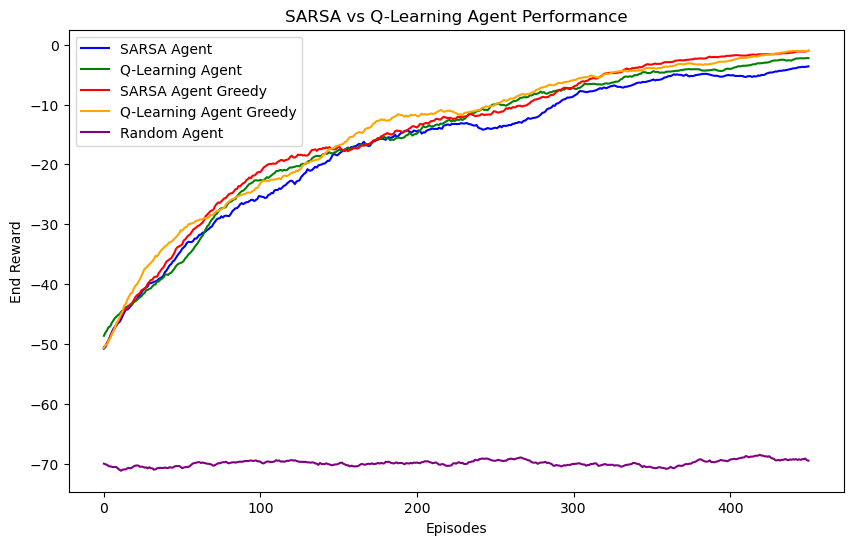

AUC SARSA : -8978.126
AUC Q-Learning : -8377.383
AUC SARSA Greedy: -7982.9842499999995
AUC Q-Learning Greedy: -7821.601999999999
AUC Random Agent: -34909.49425


In [108]:
# TODO: run the simulation
def run_simulation(agent, env: TaskEnv, n_episodes: int = 500) -> List[float]:
    episode_rewards = []
    for episode in tqdm(range(n_episodes)):
        state = env.reset()
        action = agent.select_action(state)
        done = False
        total_reward = 0.0

        while not done:
            next_state, reward, done, _ = env.step(action)
            next_action = agent.select_action(next_state)
            agent.learn(state, action, next_state, next_action, reward, done)
            action, state = next_action, next_state
            total_reward += reward

        episode_rewards.append(total_reward)
    return episode_rewards
env.reset()
random_agent = RandomAgent(env)
sarsa_agent = sarsaAgent(env)
qlearning_agent = qLearningAgent(env)

random_rewards = run_simulation(random_agent, env)
sarsa_rewards = run_simulation(sarsa_agent, env)
qlearning_rewards = run_simulation(qlearning_agent, env)
print("Random Agent Rewards:", random_rewards)
print("SARSA Agent Rewards:", sarsa_rewards)
print("Q-Learning Agent Rewards:", qlearning_rewards)
def curveSmoother(data, window_size=50):
    weights = np.ones(window_size) / window_size
    return np.convolve(data, weights, mode='valid')

def runAgentNTimes(agentClass, env: TaskEnv, n_runs: int = 5, n_episodes: int = 500, epsilon: float = 0.1) -> List[float]:
    average_rewards = np.zeros(n_episodes)
    for run in range(n_runs):
        agent = agentClass(env, exploration_rate=epsilon)
        rewards = run_simulation(agent, env, n_episodes)
        average_rewards += np.array(rewards)/n_runs
    return average_rewards
averaged_sarsa_rewards = runAgentNTimes(sarsaAgent, env, n_runs=20, n_episodes=500, epsilon=0.1)
averaged_qlearning_rewards = runAgentNTimes(qLearningAgent, env, n_runs=20, n_episodes=500, epsilon=0.1)
averaged_sarsa_rewards_greedy = runAgentNTimes(sarsaAgent, env, n_runs=20, n_episodes=500, epsilon=0)
averaged_qlearning_rewards_greedy = runAgentNTimes(qLearningAgent, env, n_runs=20, n_episodes=500, epsilon=0)
averaged_random_rewards = runAgentNTimes(RandomAgent, env, n_runs=20, n_episodes=500, )

plt.figure(figsize=(10, 6))
plt.plot(curveSmoother(averaged_sarsa_rewards), label='SARSA Agent', color='blue')
plt.plot(curveSmoother(averaged_qlearning_rewards), label='Q-Learning Agent', color='green')
plt.plot(curveSmoother(averaged_sarsa_rewards_greedy), label='SARSA Agent Greedy', color='red')
plt.plot(curveSmoother(averaged_qlearning_rewards_greedy), label='Q-Learning Agent Greedy', color='orange')
plt.plot(curveSmoother(averaged_random_rewards), label='Random Agent', color='purple')

plt.title('SARSA vs Q-Learning Agent Performance')
plt.xlabel('Episodes')
plt.ylabel('End Reward')
plt.legend()
plt.show()

episodes = np.arange(len(averaged_sarsa_rewards))
auc_sarsa = auc(episodes, averaged_sarsa_rewards)
auc_qlearning = auc(episodes, averaged_qlearning_rewards)
auc_sarsa_greedy = auc(episodes, averaged_sarsa_rewards_greedy)
auc_qlearning_greedy = auc(episodes, averaged_qlearning_rewards_greedy)
auc_randon = auc(episodes, averaged_random_rewards)
print(f"AUC SARSA : {auc_sarsa}")
print(f"AUC Q-Learning : {auc_qlearning}")
print(f"AUC SARSA Greedy: {auc_sarsa_greedy}")
print(f"AUC Q-Learning Greedy: {auc_qlearning_greedy}")
print(f"AUC Random Agent: {auc_randon}")

 ## 3. Play with parameters and analyse results
 
Finally, you will describe, evaluate, and interpret the results obtained from the two RL agents. Additionally, compare your agents with the provided Random Agent. Feel free to utilize the provided helper functions for evaluating your agents. Some important points are:

- Both quantified evaluation and human evaluation are needed in the report. The quantified evaluation should focus on the measurement of reward. In the human evaluation, you can use the provided visual tools to interpret your results. Your report should include at least one plot presenting comparable measures for the different agents.

- While evaluating the results of Agent 2 (with SARSA algorithm), please try at least 2 different values of **epsilon** (expect 0) and discuss the influence of different epsilon values on the results. In the end, please identify a reasonable epsilon value that could balance the exploration and exploitation, then fix this value for comparing the two agents. Present your trails and results in the report.

- In the report, you also need to parcitularly describe and discuss the similarity and difference of results from two RL agents (hint: on-policy VS off-policy). For this, please make sure that the compared results are obtained from the same environment (the same maze for two different agents). Also, while evaluating the results of two agents, please try at least 2 different values of **gamma**. In this way, you could discuss the influence of this discount factor in your report. 

- Please run the simulation multiple times and average the results for all your findings.


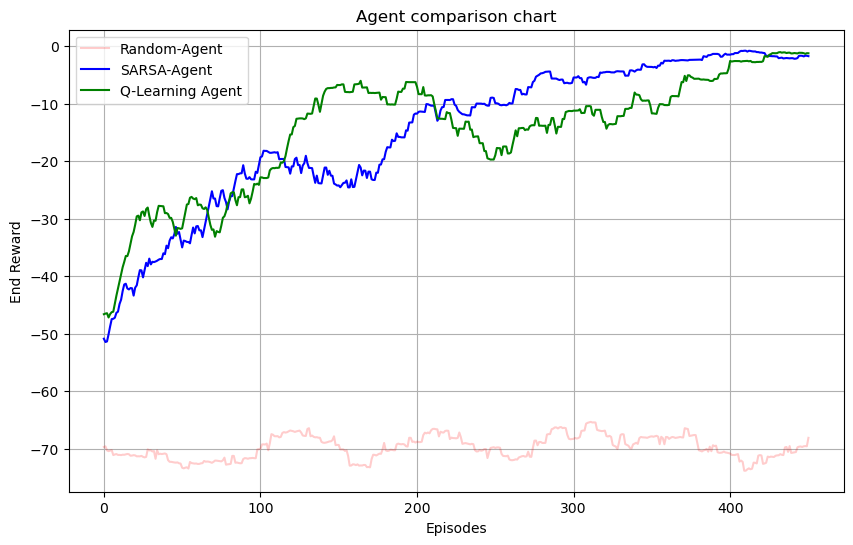

In [109]:
# TODO: evaluation 

# import packages
import matplotlib.pyplot as plt



plt.figure(figsize=(10, 6))
plt.plot(curveSmoother(random_rewards), label='Random-Agent', color='red', alpha=0.2)
plt.plot(curveSmoother(sarsa_rewards), label='SARSA-Agent', color='blue')
plt.plot(curveSmoother(qlearning_rewards), label='Q-Learning Agent', color='green')
plt.title('Agent comparison chart')
plt.xlabel('Episodes')
plt.ylabel('End Reward')
plt.legend()
plt.grid(True)
plt.show()

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

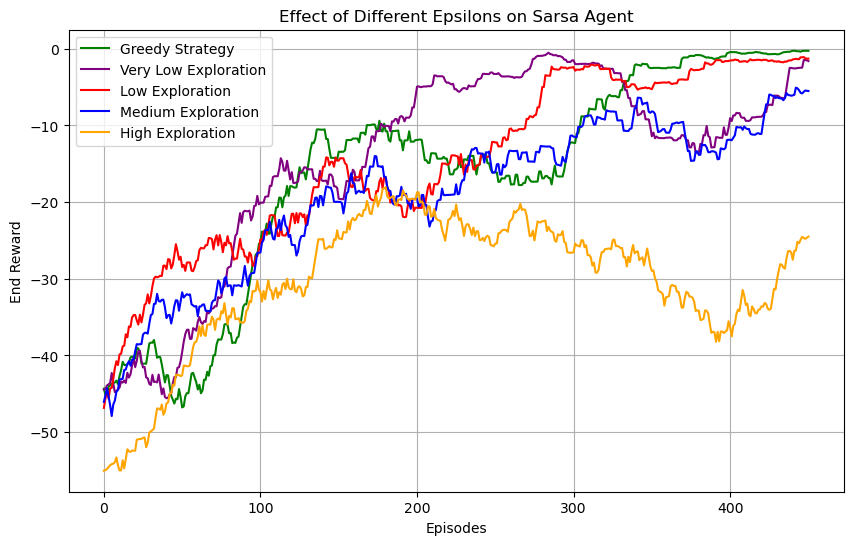

In [110]:
# Epsilon experimenting (SARSA)
sarsa_greedy = sarsaAgent(env, exploration_rate=0.0)
r_sarsa_greedy = run_simulation(sarsa_greedy, env)

sarsa_very_low = sarsaAgent(env, exploration_rate=0.01)
r_sarsa_very_low = run_simulation(sarsa_very_low, env)

sarsa_low = sarsaAgent(env, exploration_rate=0.1)
r_sarsa_low = run_simulation(sarsa_low, env)

sarsa_medium = sarsaAgent(env, exploration_rate=0.2)
r_sarsa_medium = run_simulation(sarsa_medium, env)

sarsa_high = sarsaAgent(env, exploration_rate=0.5)
r_sarsa_high = run_simulation(sarsa_high, env)



plt.figure(figsize=(10, 6))
plt.plot(curveSmoother(r_sarsa_greedy), label='Greedy Strategy', color='green')
plt.plot(curveSmoother(r_sarsa_very_low), label='Very Low Exploration', color='purple')
plt.plot(curveSmoother(r_sarsa_low), label='Low Exploration', color='red')
plt.plot(curveSmoother(r_sarsa_medium), label='Medium Exploration', color='blue')
plt.plot(curveSmoother(r_sarsa_high), label='High Exploration', color='orange')
plt.title('Effect of Different Epsilons on Sarsa Agent')
plt.xlabel('Episodes')
plt.ylabel('End Reward')
plt.legend()
plt.grid(True)
plt.show()

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

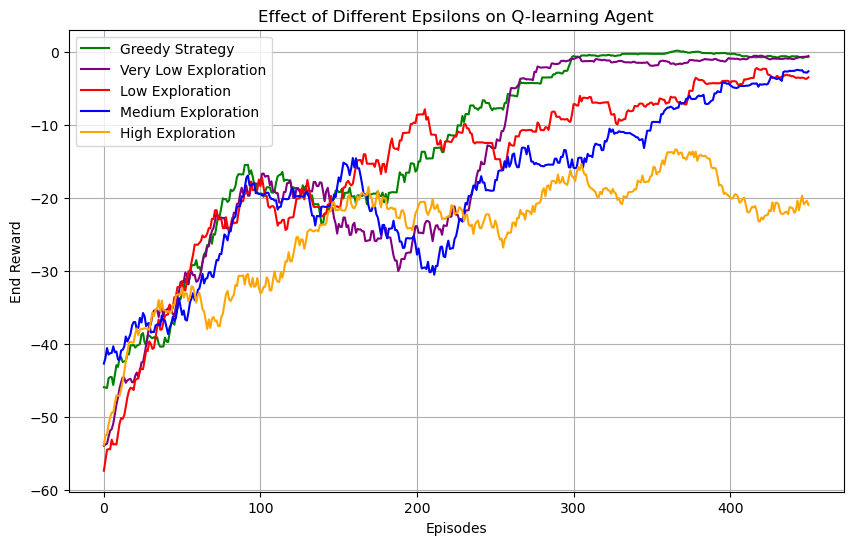

In [111]:
# Epsilon experimenting (Q-Learning)
qlearn_greedy = qLearningAgent(env, exploration_rate=0.0)
r_qlearn_greedy = run_simulation(qlearn_greedy, env)

qlearn_very_low = qLearningAgent(env, exploration_rate=0.01)
r_qlearn_very_low = run_simulation(qlearn_very_low, env)

qlearn_low = qLearningAgent(env, exploration_rate=0.1)
r_qlearn_low = run_simulation(qlearn_low, env)

qlearn_medium = qLearningAgent(env, exploration_rate=0.2)
r_qlearn_medium = run_simulation(qlearn_medium, env)

qlearn_high = qLearningAgent(env, exploration_rate=0.5)
r_qlearn_high = run_simulation(qlearn_high, env)





plt.figure(figsize=(10, 6))
plt.plot(curveSmoother(r_qlearn_greedy), label='Greedy Strategy', color='green')
plt.plot(curveSmoother(r_qlearn_very_low), label='Very Low Exploration', color='purple')
plt.plot(curveSmoother(r_qlearn_low), label='Low Exploration', color='red')
plt.plot(curveSmoother(r_qlearn_medium), label='Medium Exploration', color='blue')
plt.plot(curveSmoother(r_qlearn_high), label='High Exploration', color='orange')
plt.title('Effect of Different Epsilons on Q-learning Agent')
plt.xlabel('Episodes')
plt.ylabel('End Reward')
plt.legend()
plt.grid(True)
plt.show()

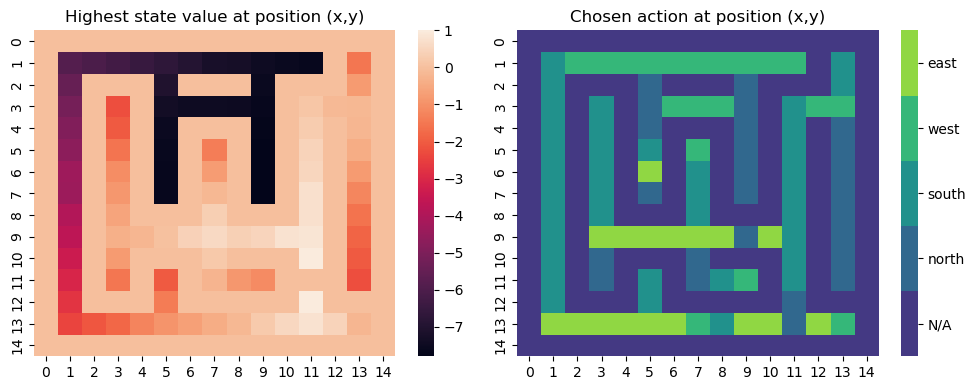

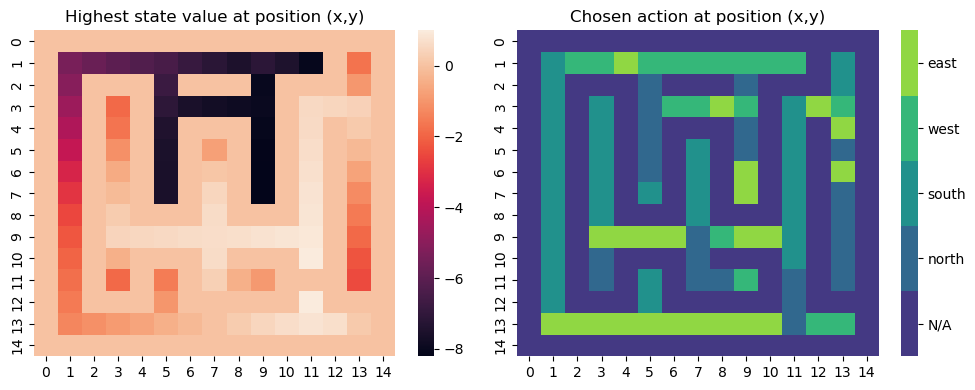

In [112]:
# Heatmaps

visualize_agent_brain(sarsa_agent, env)
visualize_agent_brain(qlearning_agent, env)

# Bonus Tasks 

We would like to challenge you with the following bonus task. For each task that is successfully completed, you may obtain max. 1 extra point. 

1. Implement a third RL agent using another RL algorithm (e.g. Monte Carlo methods, Expected SARSA or even neural network-based ones) and discuss your findings. Compare this third agent with the above ones and explain why this is a better (or worse) RL algorithm. You are allowed to reuse exsiting packages, but please cite them, test them in advance, and make sure that you can explain the used algorithm using your own words.

2. Can you explore and show other evaluation results? If so, implement and present one extra result (e.g. a plot). And please explain why it is a good evaluation method for our task or how it shows the difference between two RL agents/algorithms.

In [113]:
# Visualize the agent's behavior in the maze
def visualize_agent_run(agent, env: TaskEnv):
    env.reset()
    imgs = []
    rewards = 0.0
    done = False
    state, _ = env.reset()
    while not done:
        action = agent.select_action(state, use_greedy_strategy=True)  # Use greedy strategy for visualization
        next_state, reward, done, _ = env.step(action)
        rewards += reward
        imgs.append(env.render("rgb_array"))
        state = next_state
    print(f"Total reward: {rewards}")
    animate_run(imgs)
    plt.show()

# Example: Visualize the SARSA agent's behavior
print("Visualizing SARSA Agent")
visualize_agent_run(sarsa_agent, env)

# Example: Visualize the Q-learning agent's behavior
print("Visualizing Q-Learning Agent")
visualize_agent_run(qlearning_agent, env)

# Visualize the learned Q-table for SARSA agent
print("Visualizing SARSA Agent's Q-Table")
visualize_agent_brain(sarsa_agent, env)

# Visualize the learned Q-table for Q-learning agent
print("Visualizing Q-Learning Agent's Q-Table")
visualize_agent_brain(qlearning_agent, env)

Visualizing SARSA Agent


TypeError: cannot unpack non-iterable numpy.int64 object